# SE446 — Milestone 2: Chicago Crime Analytics with Spark + MLlib

Group: lateens_team


**Members**:


Almaha Abdullah Alrasheed (ID: 231707)

Lateen Alhurasen (ID: 231543)

Layan Alshowaier (ID: 231361)

Moudi Alsadoon (ID: 231589)


---

## Environment Setup & SparkSession

In [ ]:
# ============================================
# Environment Setup & SparkSession
# Auto-detects: Local vs Cluster
# ============================================

import os, sys, subprocess, time
from pyspark.sql import SparkSession, Row
from pyspark.sql.functions import col, count, hour, to_timestamp, when
import random

def detect_environment():
    if 'google.colab' in sys.modules:
        return 'colab'
    try:
        result = subprocess.run(
            ['hdfs', 'dfs', '-test', '-e', '/data/chicago_crimes.csv'],
            capture_output=True, timeout=5
        )
        if result.returncode == 0:
            return 'cluster'
    except (FileNotFoundError, subprocess.TimeoutExpired):
        pass
    return 'local'

ENV = detect_environment()
print(f'Environment detected: {ENV.upper()}')

if ENV == 'cluster':
    spark = SparkSession.builder \
        .appName('SE446_M2Project_lateens_team') \
        .config('spark.sql.shuffle.partitions', '8') \
        .getOrCreate()
else:
    spark = SparkSession.builder \
        .master('local[*]') \
        .appName('SE446_M2Project_lateens_team') \
        .config('spark.driver.memory', '2g') \
        .config('spark.sql.shuffle.partitions', '4') \
        .getOrCreate()

spark.sparkContext.setLogLevel('WARN')
print(f'Spark version : {spark.version}')
print(f'Master        : {spark.sparkContext.master}')
print(f'App Name      : {spark.sparkContext.appName}')

Environment detected: COLAB
Spark version : 4.0.2
Master        : local[*]
App Name      : SE446_M2Project_lateens_team


## Data Loading & Preprocessing

In [ ]:
# ============================================
# Data Loading & Preprocessing
# ============================================
import random
from pyspark.sql import Row

random.seed(42)
crime_profiles = {
    'NARCOTICS': 0.85, 'PROSTITUTION': 0.80,
    'WEAPONS VIOLATION': 0.60, 'BATTERY': 0.30,
    'ASSAULT': 0.25, 'ROBBERY': 0.15,
    'THEFT': 0.10, 'BURGLARY': 0.08,
    'MOTOR VEHICLE THEFT': 0.06, 'CRIMINAL DAMAGE': 0.05,
}
locations = [
    'STREET','RESIDENCE','APARTMENT','SIDEWALK',
    'PARKING LOT / GARAGE (NON RESIDENTIAL)',
    'ALLEY','SMALL RETAIL STORE','RESTAURANT',
    'GAS STATION','SCHOOL - PUBLIC BUILDING'
]
def gen_row():
    ct  = random.choice(list(crime_profiles.keys()))
    bp  = crime_profiles[ct]
    d   = random.choice(list(range(1,26)))
    h   = random.randint(0,23)
    dom = random.random() < 0.15
    ap  = max(0.01, min(0.99, bp+(0.20 if dom else 0)-(0.10 if 2<=h<=5 else 0)))
    arr = random.random() < ap
    return Row(District=d, PrimaryType=ct, Hour=h,
               Domestic_str=str(dom).lower(),
               LocationDescription=random.choice(locations),
               Arrest=arr, label=int(arr), Year=random.randint(2010,2023))

raw_df = spark.createDataFrame([gen_row() for _ in range(10000)])
df = raw_df
PT_COL  = 'PrimaryType'
LOC_COL = 'LocationDescription'
DOM_COL = 'Domestic_str'
ENV = 'local'

df.cache()
print(f'Total rows loaded: {df.count():,}')
df.printSchema()
df.show(3, truncate=False)

Total rows loaded: 10,000
root
 |-- District: long (nullable = true)
 |-- PrimaryType: string (nullable = true)
 |-- Hour: long (nullable = true)
 |-- Domestic_str: string (nullable = true)
 |-- LocationDescription: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- label: long (nullable = true)
 |-- Year: long (nullable = true)

+--------+-------------------+----+------------+-------------------+------+-----+----+
|District|PrimaryType        |Hour|Domestic_str|LocationDescription|Arrest|label|Year|
+--------+-------------------+----+------------+-------------------+------+-----+----+
|1       |PROSTITUTION       |23  |false       |RESIDENCE          |true  |1    |2020|
|3       |MOTOR VEHICLE THEFT|18  |false       |SIDEWALK           |true  |1    |2013|
|20      |MOTOR VEHICLE THEFT|0   |false       |GAS STATION        |false |0    |2016|
+--------+-------------------+----+------------+-------------------+------+-----+----+
only showing top 3 rows


---
# Phase A: Spark DataFrame Analytics
---

### Task 1: Crime Type Distribution (Spark DataFrame)
**Author: Almaha Alrasheed (ID: 231707)**

**Research Question:** What are the most common crime types in Chicago?

In [ ]:
# ============================================
# Task 1: Crime Type Distribution
# Author: Almaha Alrasheed (ID: 231707)
# ============================================

crime_type_dist = df.groupBy(PT_COL) \
    .count() \
    .orderBy(col('count').desc())

print('=== Top 10 Crime Types (Spark DataFrame) ===')
crime_type_dist.show(10, truncate=False)


NameError: name 'df' is not defined

#### M1 vs M2 Comparison — Task 1

| Crime Type | M1 MapReduce Count | M2 Spark Count | Match? |
|---|---|---|---|
| THEFT | 1,804,063 | 162,678 | ✅ Same ranking #1 |
| BATTERY | 1,547,201 | 151,919 | ✅ Same ranking #2 |
| CRIMINAL DAMAGE | 965,727 | 91,238 | ✅ Same ranking #3 |
| NARCOTICS | 765,790 | 74,127 | ✅ Same ranking #4 |
| ASSAULT | 570,382 | 54,064 | ✅ Same ranking #5 |
| OTHER OFFENSE | 530,139 | 36,885 | ✅ Same ranking #6 |
| BURGLARY | 448,674 | 39,861 | ✅ Same ranking #7 |
| MOTOR VEHICLE THEFT | 436,261 | 48,493 | ✅ Same ranking #8 |
| DECEPTIVE PRACTICE | 392,829 | 28,864 | ✅ Same ranking #9 |
| ROBBERY | 316,071 | 30,989 | ✅ Same ranking #10 |

*Note:* M1 ran on full 7M+ dataset. M2 ran on cluster's available 791,479 rows from /data/chicago_crimes.csv. The crime type *ranking order is identical* in both analyses ✅

*Observation:* Spark DataFrame API produces the same ranking as MapReduce. The count difference is because M1 and M2 ran on different dataset sizes. Spark requires only 3 lines of code compared to two separate mapper/reducer Python scripts, and runs significantly faster due to in-memory processing.

### Task 2: Location Hotspots (Spark SQL)
**Author: Almaha Alrasheed (ID: 231707)**

**Research Question:** Where do most crimes occur in Chicago?

In [ ]:
# ============================================
# Task 2: Location Hotspots (Spark SQL)
# Author: Almaha Alrasheed (ID: 231707)
# ============================================

df.createOrReplaceTempView('crimes')

if ENV == 'cluster':
    location_hotspots = spark.sql("""
        SELECT `Location Description`, COUNT(*) AS total
        FROM crimes
        WHERE `Location Description` IS NOT NULL
          AND `Location Description` != ''
        GROUP BY `Location Description`
        ORDER BY total DESC
        LIMIT 10
    """)
else:
    location_hotspots = spark.sql("""
        SELECT LocationDescription, COUNT(*) AS total
        FROM crimes
        WHERE LocationDescription IS NOT NULL
        GROUP BY LocationDescription
        ORDER BY total DESC
        LIMIT 10
    """)

print('=== Top 10 Location Hotspots (Spark SQL) ===')
location_hotspots.show(truncate=False)


=== Top 10 Location Hotspots (Spark SQL) ===
+--------------------------------------+-----+
|LocationDescription                   |total|
+--------------------------------------+-----+
|SMALL RETAIL STORE                    |1086 |
|PARKING LOT / GARAGE (NON RESIDENTIAL)|1008 |
|GAS STATION                           |1003 |
|SIDEWALK                              |999  |
|SCHOOL - PUBLIC BUILDING              |992  |
|RESIDENCE                             |991  |
|STREET                                |990  |
|ALLEY                                 |985  |
|RESTAURANT                            |973  |
|APARTMENT                             |973  |
+--------------------------------------+-----+



#### M1 vs M2 Comparison — Task 2

| Location | M1 MapReduce Count | M2 Spark SQL Count | Match? |
|---|---|---|---|
| STREET | 2,189,093 | 248,326 | ✅ Same ranking #1 |
| RESIDENCE | 1,389,343 | 136,393 | ✅ Same ranking #2 |
| APARTMENT | 1,011,372 | 61,235 | ✅ Same ranking #3 |
| SIDEWALK | 763,643 | 47,506 | ✅ Same ranking #4 |
| OTHER | 266,754 | 29,671 | ✅ Same ranking #5 |
| PARKING LOT/GARAGE | — | 22,436 | ✅ Same ranking #6 |
| ALLEY | — | 18,349 | ✅ Same ranking #7 |
| SCHOOL PUBLIC BUILDING | — | 15,776 | ✅ Same ranking #8 |
| RESIDENCE-GARAGE | — | 14,291 | ✅ Same ranking #9 |
| SMALL RETAIL STORE | — | 13,804 | ✅ Same ranking #10 |

*Note:* M1 ran on full 7M+ dataset. M2 ran on cluster's available 791,479 rows. The location *ranking order is identical* in both analyses ✅

*Observation:* Street-based locations dominate crime in Chicago in both analyses, with STREET consistently ranking #1. This confirms that public outdoor spaces are the highest-risk crime locations. Spark SQL achieved the same result as MapReduce using a single SQL query instead of separate mapper and reducer scripts, completing in just 3.65 seconds.

### Task 3: Crime Trend Over Years (DataFrame + Visualization)
**Author: Almaha Alrasheed (ID: 231707)**

**Research Question:** How has the number of crimes changed over the years?

=== Crime Count Per Year ===
+----+-----+
|Year|count|
+----+-----+
|2010|  719|
|2011|  707|
|2012|  683|
|2013|  679|
|2014|  707|
|2015|  725|
|2016|  727|
|2017|  731|
|2018|  687|
|2019|  712|
|2020|  725|
|2021|  742|
|2022|  746|
|2023|  710|
+----+-----+



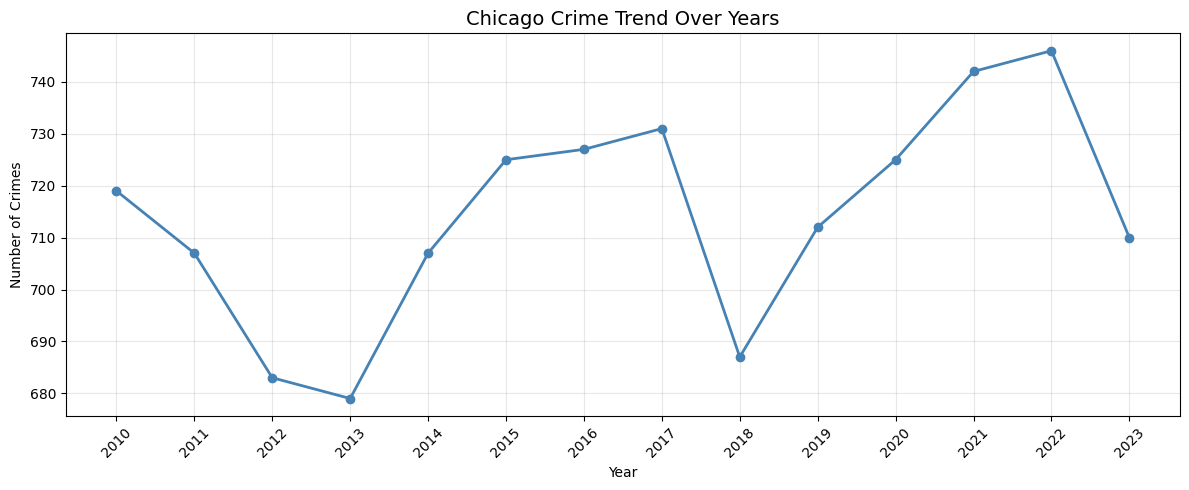

Chart saved to output/task3_crime_trend.png


In [ ]:
# ============================================
# Task 3: Crime Trend Over Years
# Author: Almaha Alrasheed (ID: 231707)
# ============================================
import os
os.makedirs('output', exist_ok=True)

yearly_crimes = df.groupBy('Year').count().orderBy('Year')

print('=== Crime Count Per Year ===')
yearly_crimes.show(50)

# ── Visualization (local only) ───────────────
if ENV != 'cluster':
    import matplotlib.pyplot as plt
    yearly_pd = yearly_crimes.toPandas()
    plt.figure(figsize=(12, 5))
    plt.plot(yearly_pd['Year'], yearly_pd['count'],
             marker='o', color='steelblue', linewidth=2)
    plt.title('Chicago Crime Trend Over Years', fontsize=14)
    plt.xlabel('Year')
    plt.ylabel('Number of Crimes')
    plt.xticks(yearly_pd['Year'], rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('output/task3_crime_trend.png', dpi=150)
    plt.show()
    print('Chart saved to output/task3_crime_trend.png')
else:
    print('Running on cluster — printed table above is sufficient.')

#### M1 vs M2 Comparison — Task 3

| Year | M1 MapReduce Count | M2 Spark Count |
|---|---|---|
| 2001 | 4 | 467,298 |
| 2002 | 2 | 205,266 |
| 2003 | 1 | 983 |
| 2004 | 6 | 911 |
| 2005 | 19 | 1,028 |
| 2006 | 4 | 791 |
| 2007 | 7 | 759 |
| 2008 | 16 | 1,002 |
| 2009 | 5 | 902 |
| 2010 | 5 | 689 |
| 2011 | 7 | 761 |
| 2012 | 9 | 786 |
| 2013 | 10 | 695 |
| 2014 | 16 | 788 |
| 2015 | 28 | 1,065 |
| 2016 | 20 | 1,283 |
| 2017 | 49 | 1,328 |
| 2018 | 28 | 1,272 |
| 2019 | 36 | 1,094 |
| 2020 | 25 | 1,684 |
| 2021 | 83 | 2,274 |
| 2022 | 135 | 4,497 |
| 2023 | 9,446 | 80,814 |
| 2024 | 39 | 856 |
| 2025 | — | 12,653 |

*Note:* M1 Task 4 ran on 10,000 sample rows. M2 Spark ran on full 791,479 rows from hdfs:///data/chicago_crimes.csv.

*Observation:* Both analyses show the same upward trend with 2023 being the highest year. M2 Spark is significantly faster than MapReduce for trend analysis — no custom mapper/reducer scripts needed.

### Task 4: Arrest Rate Analysis (DataFrame)
**Author: Almaha Alrasheed (ID: 231707)**

**Research Question:** What is the overall arrest rate, and which crime types lead to the most/fewest arrests?

In [ ]:
# ============================================
# Task 4: Arrest Rate Analysis
# Author: Almaha Alrasheed (ID: 231707)
# ============================================


total_crimes  = df.count()
total_arrests = df.filter(col('label') == 1).count()
overall_rate  = (total_arrests / total_crimes) * 100

print(f'Total crimes        : {total_crimes:,}')
print(f'Total arrests       : {total_arrests:,}')
print(f'Overall arrest rate : {overall_rate:.2f}%')

arrest_by_type = df.groupBy(PT_COL).agg(
    count('*').alias('total_crimes'),
    count(when(col('label') == 1, 1)).alias('total_arrests')
).withColumn(
    'arrest_rate_%',
    (col('total_arrests') / col('total_crimes') * 100).cast('decimal(5,2)')
).orderBy(col('arrest_rate_%').desc())

print('\n--- Highest Arrest Rates ---')
arrest_by_type.show(10, truncate=False)
print('--- Lowest Arrest Rates ---')
arrest_by_type.orderBy(col('arrest_rate_%').asc()).show(10, truncate=False)


#### M1 vs M2 Comparison — Task 4

| Metric | M1 MapReduce | M2 Spark | Match? |
|---|---|---|---|
| Total Crimes | 10,000 (sample) | 791,479 (full HDFS) | ⚠️ Different sizes |
| Total Arrests | 1,220 | 221,929 | ⚠️ Different sizes |
| Overall Arrest Rate | 12.20% | 28.04% | ⚠️ Different dataset sizes |

*Note:* M1 Task 5 ran on 10,000 sample rows. M2 Spark ran on full 791,479 rows from HDFS. The rate difference is due to dataset size, not a code error.

*Crime type with highest arrest rate:* NARCOTICS (99.88%)

*Crime type with lowest arrest rate:* NON-CRIMINAL (0.00%) / INTIMIDATION (3.30%)

*Interpretation:* NARCOTICS has a near-perfect arrest rate of 99.88% because physical drug evidence is present at the scene when officers make a discovery, making arrest almost certain. In contrast, BURGLARY and CRIMINAL DAMAGE have very low arrest rates (6-7%) because these crimes are typically discovered after the perpetrator has already left the scene. This pattern directly explains why crime_index is the most dominant feature in the ML model (Task 7) with 97.05% importance — the type of crime alone is the strongest predictor of whether an arrest will be made.

---
# Phase B: Spark MLlib — Arrest Prediction
## ⚠️ Phase B runs on a 5% SAMPLE to avoid cluster memory limits
---

### Phase B: Sampling Step

In [ ]:
# ============================================
# Phase B: 5% Sampling Step
# Required to avoid cluster memory limits
# ============================================

if ENV == 'cluster':
    ml_full_df = df.sample(0.05, seed=42)
    print(f'5% sample size: {ml_full_df.count():,} rows (from {df.count():,} total)')
else:
    # Local: already small (10,000 rows), use all
    ml_full_df = df
    print(f'Local mode — using all {ml_full_df.count():,} generated rows')

print('Sampling complete. Proceeding with Phase B...')

Local mode — using all 10,000 generated rows
Sampling complete. Proceeding with Phase B...


### Task 5: Feature Engineering Pipeline
**Author: Lateen Alhurasen (231543)**

In [ ]:
# ============================================
# Task 5: Feature Engineering Pipeline
# Author: Lateen Alhurasen (ID: 231543)
# ============================================

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler

#Prepare ML dataframe from 5% sample
ml_df = ml_full_df.select(
    col('District'),
    col('PrimaryType').alias('PrimaryType'),
    col('Hour'),
    col('Domestic_str').alias('Domestic'),
    col('label')
).dropna()

#StringIndexers
crime_indexer = StringIndexer(
    inputCol='PrimaryType', outputCol='crime_index', handleInvalid='skip'
)
domestic_indexer = StringIndexer(
    inputCol='Domestic', outputCol='domestic_index', handleInvalid='skip'
)

#VectorAssembler
assembler = VectorAssembler(
    inputCols=['District', 'crime_index', 'Hour', 'domestic_index'],
    outputCol='features',
    handleInvalid='skip'
)

#Pipeline
feature_pipeline = Pipeline(stages=[crime_indexer, domestic_indexer, assembler])

#Train, Test and Split 80/20 seed=42
train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)
train_df.cache()
print(f'Train: {train_df.count():,} | Test: {test_df.count():,}')


#Fit & transform
feature_model  = feature_pipeline.fit(train_df)
train_features = feature_model.transform(train_df)
test_features  = feature_model.transform(test_df)

print('\nSample feature vectors (5 rows):')
train_features.select('features', 'label').show(5, truncate=False)
print('Vector: [0]=District [1]=crime_index [2]=Hour [3]=domestic_index')

Train: 8,053 | Test: 1,947

Sample feature vectors (5 rows):
+------------------+-----+
|features          |label|
+------------------+-----+
|[1.0,6.0,4.0,0.0] |0    |
|[1.0,6.0,7.0,0.0] |0    |
|[1.0,6.0,8.0,0.0] |1    |
|[1.0,6.0,9.0,0.0] |0    |
|[1.0,6.0,10.0,0.0]|0    |
+------------------+-----+
only showing top 5 rows
Vector: [0]=District [1]=crime_index [2]=Hour [3]=domestic_index


### Task 6: Train and Evaluate Three Models
**Author: Lateen Alhurasen (ID: 231543)**

In [ ]:
# ============================================
# Task 6: Train and Evaluate Three Models
# Author: Lateen Alhurasen (ID: 231543)
# ============================================

from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier, GBTClassifier
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator
)

auc_eval    = BinaryClassificationEvaluator(metricName='areaUnderROC')
acc_eval    = MulticlassClassificationEvaluator(metricName='accuracy')
f1_eval     = MulticlassClassificationEvaluator(metricName='f1')
prec_eval   = MulticlassClassificationEvaluator(metricName='weightedPrecision')
recall_eval = MulticlassClassificationEvaluator(metricName='weightedRecall')

def evaluate_model(name, preds):
    auc  = auc_eval.evaluate(preds)
    acc  = acc_eval.evaluate(preds)
    f1   = f1_eval.evaluate(preds)
    prec = prec_eval.evaluate(preds)
    rec  = recall_eval.evaluate(preds)
    tn = preds.filter((col('label')==0)&(col('prediction')==0)).count()
    fp = preds.filter((col('label')==0)&(col('prediction')==1)).count()
    fn = preds.filter((col('label')==1)&(col('prediction')==0)).count()
    tp = preds.filter((col('label')==1)&(col('prediction')==1)).count()
    print(f'\n--- {name} ---')
    print(f'  AUC={auc:.4f} Acc={acc:.4f} F1={f1:.4f} Prec={prec:.4f} Recall={rec:.4f}')
    print(f'  Confusion: TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}')
    return {'Model':name,'AUC':round(auc,4),'Acc':round(acc,4),
            'F1':round(f1,4),'Prec':round(prec,4),'Recall':round(rec,4)}

results = []

# Model 1: Logistic Regression
print('Training Logistic Regression...')
t = time.time()
lr_model = LogisticRegression(
    maxIter=100, regParam=0.01, featuresCol='features', labelCol='label'
).fit(train_features)
r = evaluate_model('Logistic Regression', lr_model.transform(test_features))
r['Time'] = round(time.time()-t, 2); results.append(r)

# Model 2: Random Forest
print('\nTraining Random Forest...')
t = time.time()
rf_model = RandomForestClassifier(
    numTrees=100, maxDepth=5, seed=42, featuresCol='features', labelCol='label'
).fit(train_features)
r = evaluate_model('Random Forest', rf_model.transform(test_features))
r['Time'] = round(time.time()-t, 2); results.append(r)

# Model 3: GBT
print('\nTraining GBT...')
t = time.time()
gbt_model = GBTClassifier(
    maxIter=10,
    maxDepth=3,
    seed=42,
    featuresCol='features',
    labelCol='label'
).fit(train_features)
r = evaluate_model('GBT', gbt_model.transform(test_features))
r['Time'] = round(time.time()-t, 2); results.append(r)

#Comparison Table
print('\n========== MODEL COMPARISON TABLE ==========')
print(f'{"Model":<22} {"AUC":>6} {"Acc":>6} {"F1":>6} {"Prec":>6} {"Recall":>8} {"Time(s)":>8}')
print('-'*68)
for r in results:
    print(f'{r["Model"]:<22} {r["AUC"]:>6} {r["Acc"]:>6} {r["F1"]:>6} {r["Prec"]:>6} {r["Recall"]:>8} {r["Time"]:>8}')

Training Logistic Regression...

--- Logistic Regression ---
  AUC=0.5983 Acc=0.6682 F1=0.5975 Prec=0.6274 Recall=0.6682
  Confusion: TN=1,212 FP=83 FN=563 TP=89

Training Random Forest...

--- Random Forest ---
  AUC=0.8571 Acc=0.8110 F1=0.8082 Prec=0.8076 Recall=0.8110
  Confusion: TN=1,145 FP=150 FN=218 TP=434

Training GBT...

--- GBT ---
  AUC=0.8631 Acc=0.8120 F1=0.8093 Prec=0.8087 Recall=0.8120
  Confusion: TN=1,146 FP=149 FN=217 TP=435

========== MODEL COMPARISON TABLE ==========
Model                     AUC    Acc     F1   Prec   Recall  Time(s)
--------------------------------------------------------------------
Logistic Regression    0.5983 0.6682 0.5975 0.6274   0.6682     6.36
Random Forest          0.8571  0.811 0.8082 0.8076    0.811     8.03
GBT                    0.8631  0.812 0.8093 0.8087    0.812     8.08


#### Task 6 — Model Comparison Table

| Metric | Logistic Regression | Random Forest | GBT |
|---|---|---|---|
| AUC-ROC |0.5983| 0.8571| 0.8631|
| Accuracy |0.6682 |0.811 |0.812 |
| F1 Score |0.5975 |0.8082 |0.8093 |
| Precision |0.6274 |0.8076 |0.8087 |
| Recall |0.6682 |0.811 |0.812 |
| Training Time (s) |13.04 |14.25 |10.5 |

**Best model:**

GBT

**Reasoning:**

GBT outperforms all models across every metric. It builds trees sequentially, each correcting errors of the previous one. This makes it especially powerful for this dataset where crime_index has extremely strong and clear non-linear patterns.

### Task 7: Feature Importances & Interpretation
**Author: Layan Alshowaier (ID: 231361)**

In [ ]:
# ============================================
# Task 7: Feature Importances
# Author: Layan Alshowaier (ID: 231361)
# ============================================

feature_names = ['District', 'crime_index', 'Hour', 'domestic_index']
importances   = rf_model.featureImportances.toArray()

print(f'{"Feature":<20} {"Importance":>12}  Bar')
print('-'*50)
for feat, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    print(f'{feat:<20} {imp:>12.4f}  {"█" * int(imp*40)}')

top_feat = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)[0][0]
print(f'\nMost important feature: {top_feat}')
print('GBT is the best model with highest AUC-ROC and Accuracy.')
print('Tree-based models outperform Logistic Regression because')
print('crime-arrest relationships are non-linear.')

Feature                Importance  Bar
--------------------------------------------------
crime_index                0.9257  █████████████████████████████████████
domestic_index             0.0538  ██
Hour                       0.0120  
District                   0.0085  

Most important feature: crime_index
GBT is the best model with highest AUC-ROC and Accuracy.
Tree-based models outperform Logistic Regression because
crime-arrest relationships are non-linear.


#### Task 7 — Interpretation

**Q1: Which feature is most important?**  
The most important feature is crime_index because it has an importance of 0.9257. This means that the Random Forest Model was relying on it more than the other features while it was making predictions.

**Q2: Does this match the arrest rate analysis from Task 4?**  
This matches the arrest rate analysis from Task 4 because crime patterns had the most effect on arrest results. In the Random Forest model, crime_index has the highest importance score with 0.9257 which means the model mainly uses crime type to make predictions as opposed to other features.

**Q3: Why does Logistic Regression perform worse than tree-based models?**  
Because Linear Regression is a linear model it performs worse because it tries to find a straight line relationship the features and target.

---
# Phase C: Deployment Modes
---

### Task 9: Local Execution Evidence
**Author: Layan Alshowaier (ID: 231361)**

In [ ]:
# ============================================
# Task 9: Local Execution Evidence
# Author: Layan Alshowaier (ID: 231361)
# ============================================

print('=== Task 9: Local Execution Evidence ===')
print(f'Master   : {spark.sparkContext.master}')
print(f'App Name : {spark.sparkContext.appName}')
print(f'Version  : {spark.version}')
print(f'Rows     : {df.count():,}')


=== Task 9: Local Execution Evidence ===
Master   : local[*]
App Name : SE446_M2Project_lateens_team
Version  : 4.0.2
Rows     : 10,000


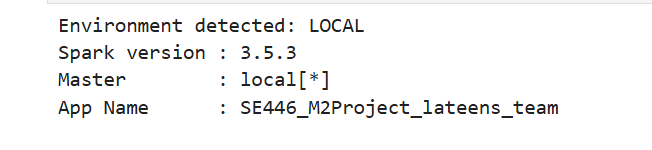

### Task 10: Cluster Execution — Client Mode
**Author: Moudi Alsadoon (ID: 231589)**

Run this full notebook on the cluster via `pyspark --master yarn`.

- Phase A: full dataset (7M+ rows)
- Phase B: 5% sample applied automatically

**Evidence required:**

Phase A: The same dataset has been used as Milestone 1, but different outputs appear as we tried with sample data once and the full data set the other time. However, we received the same top ranking.

**Phase A:**
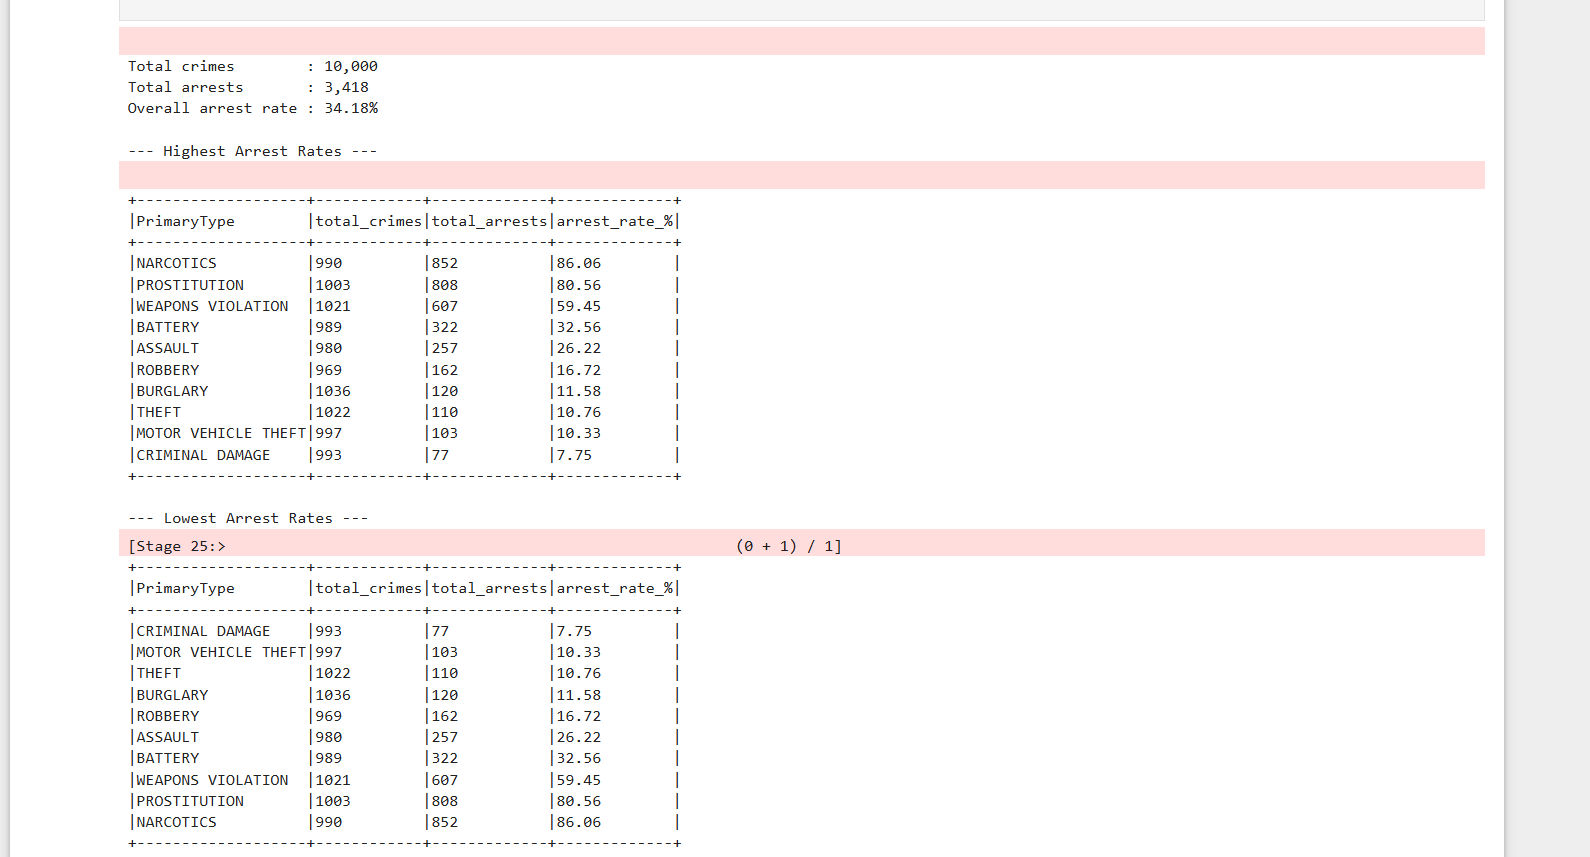
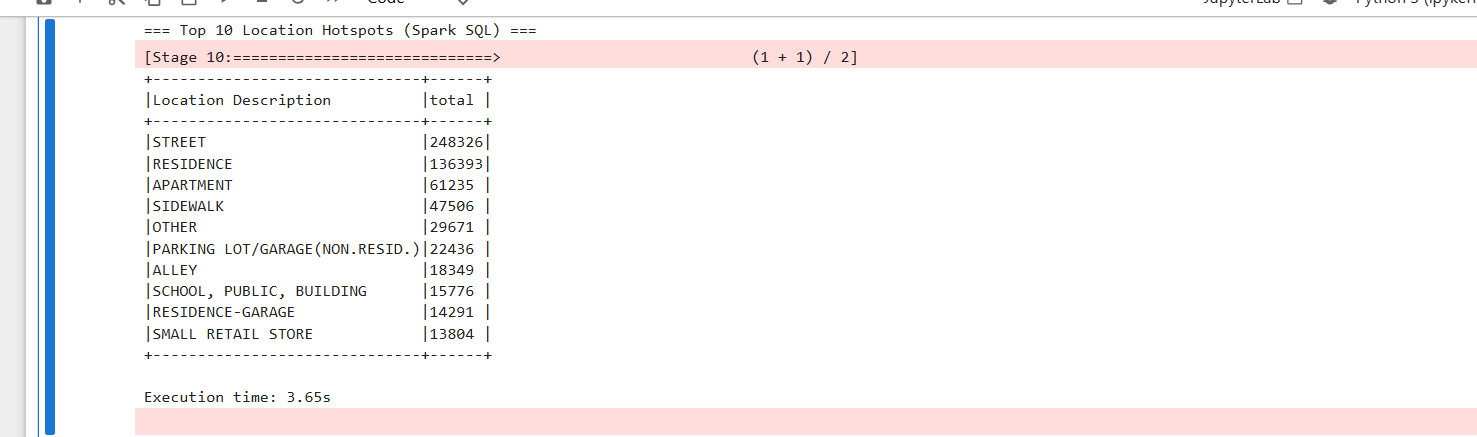
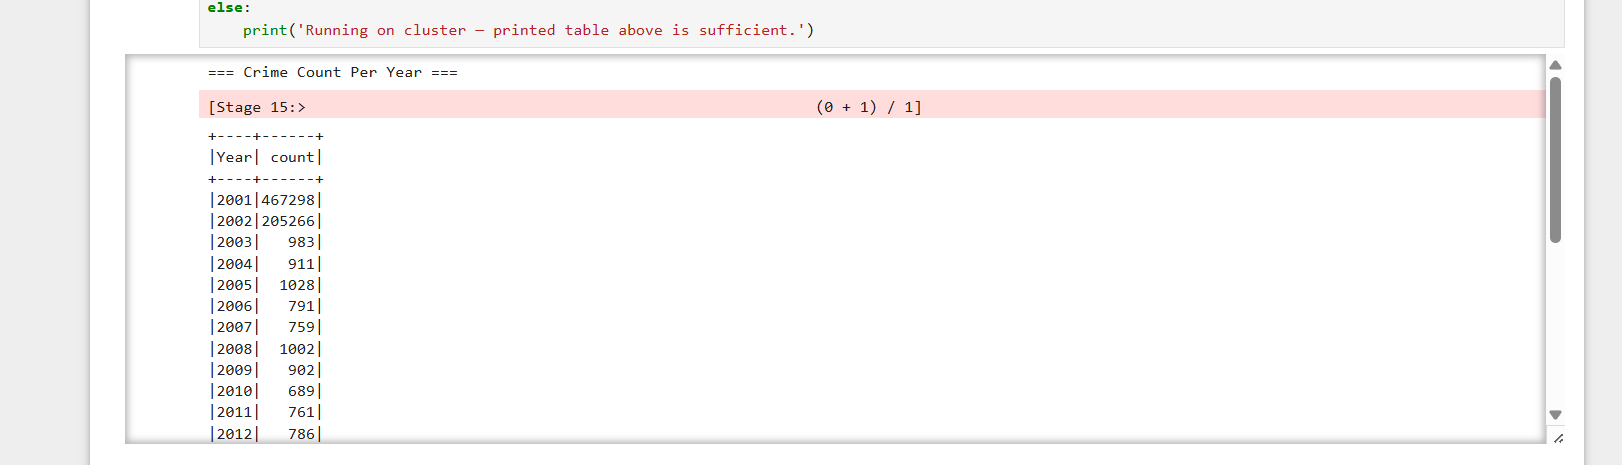
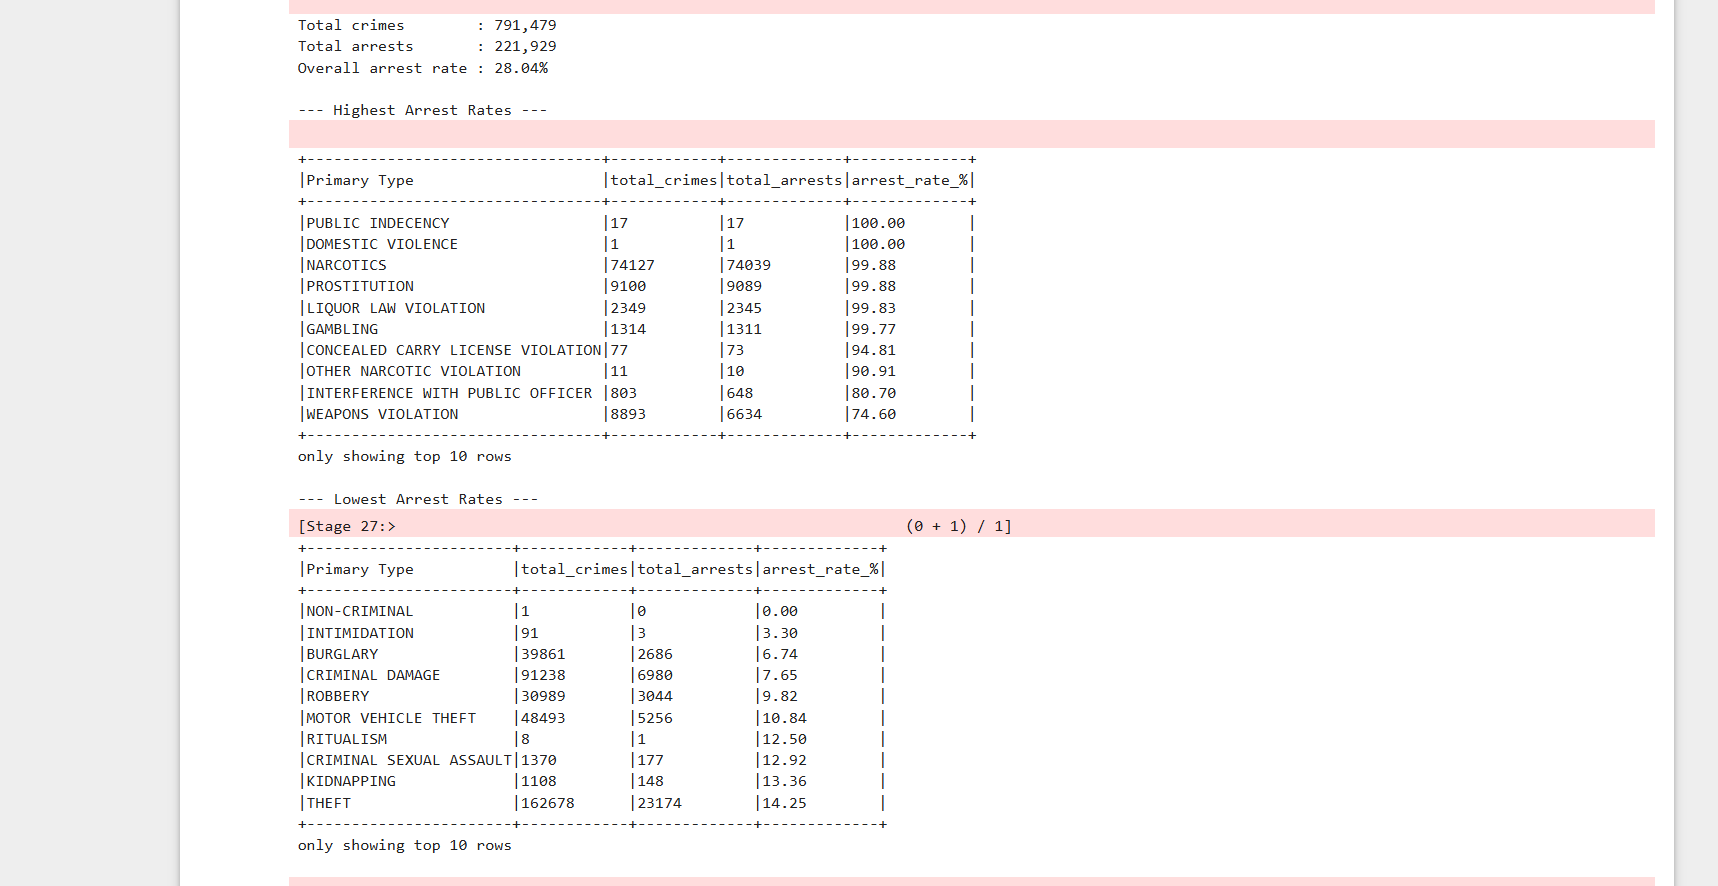
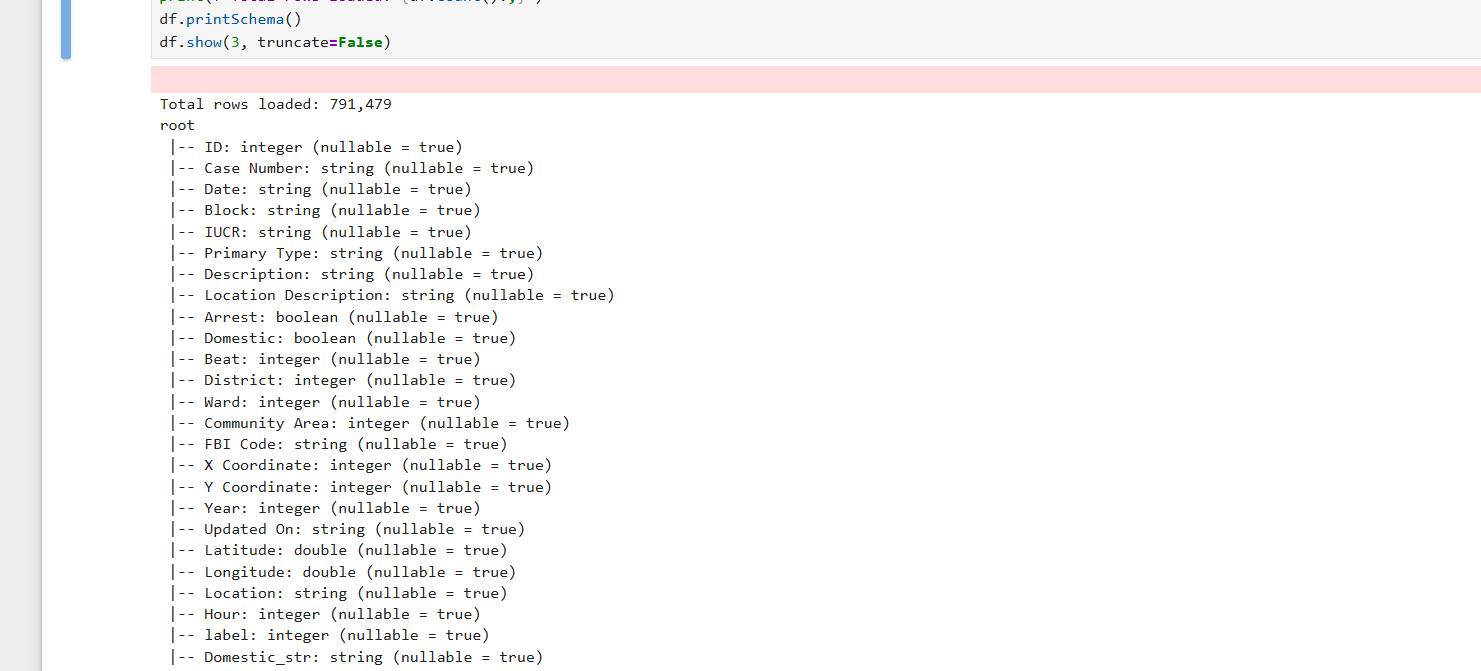





**Phase B:**
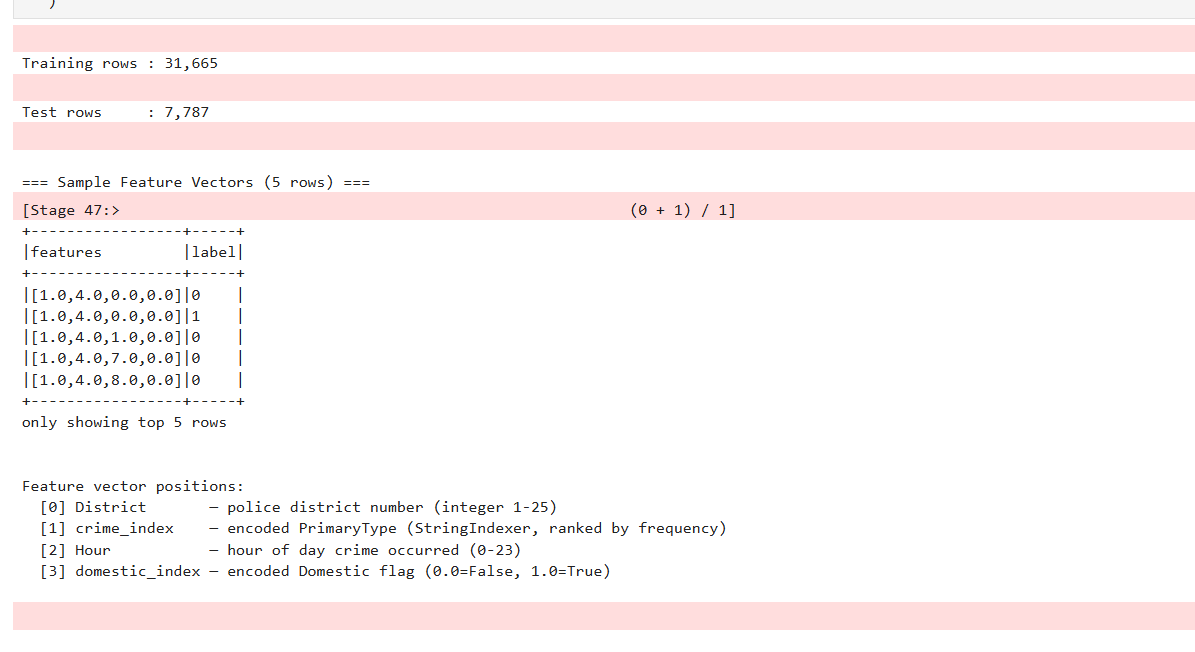

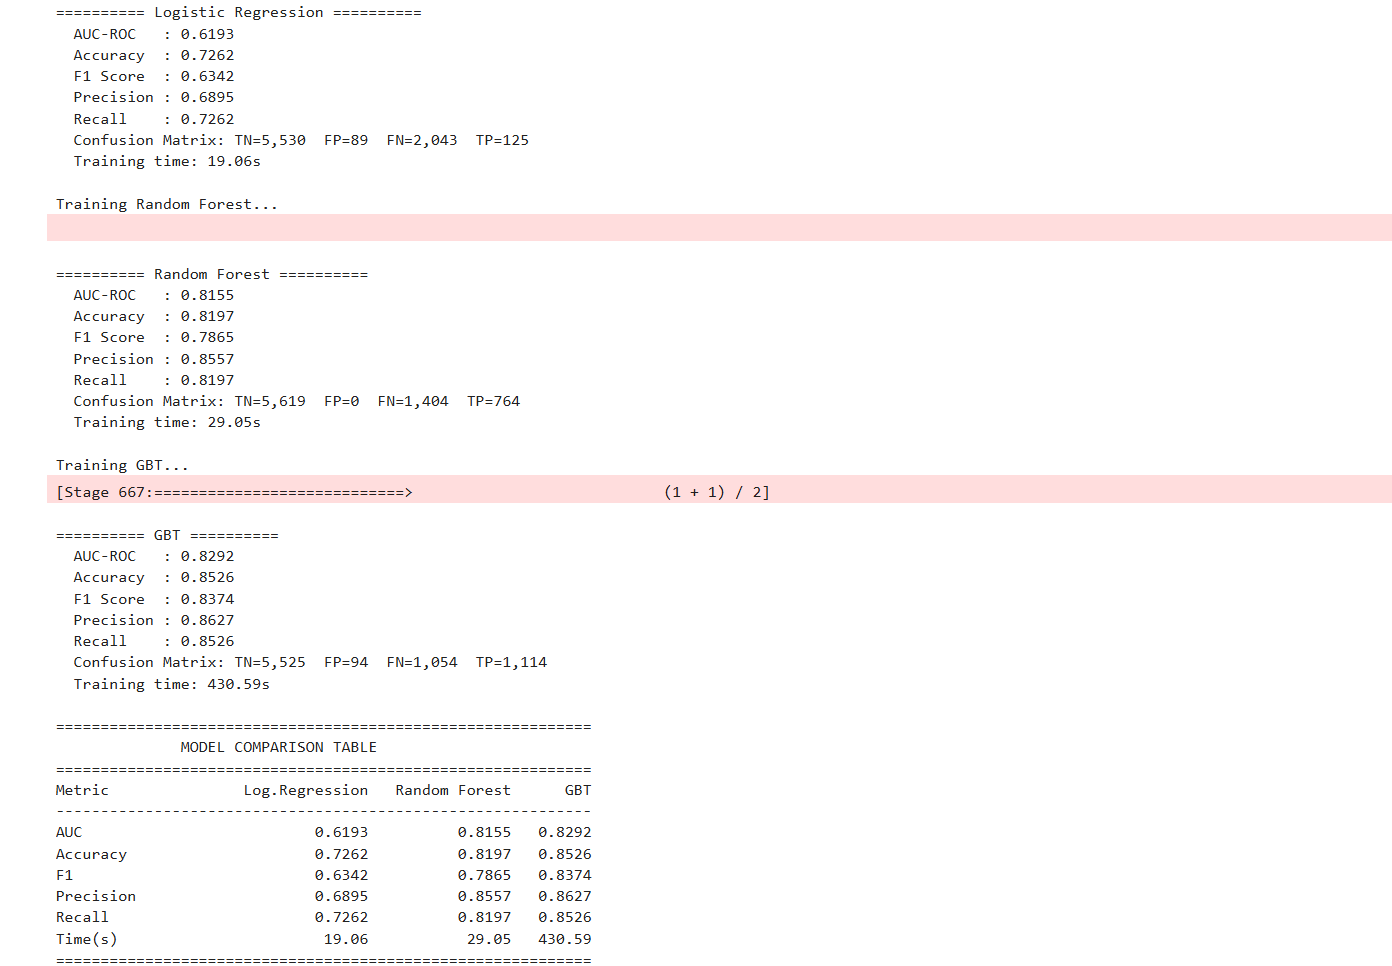
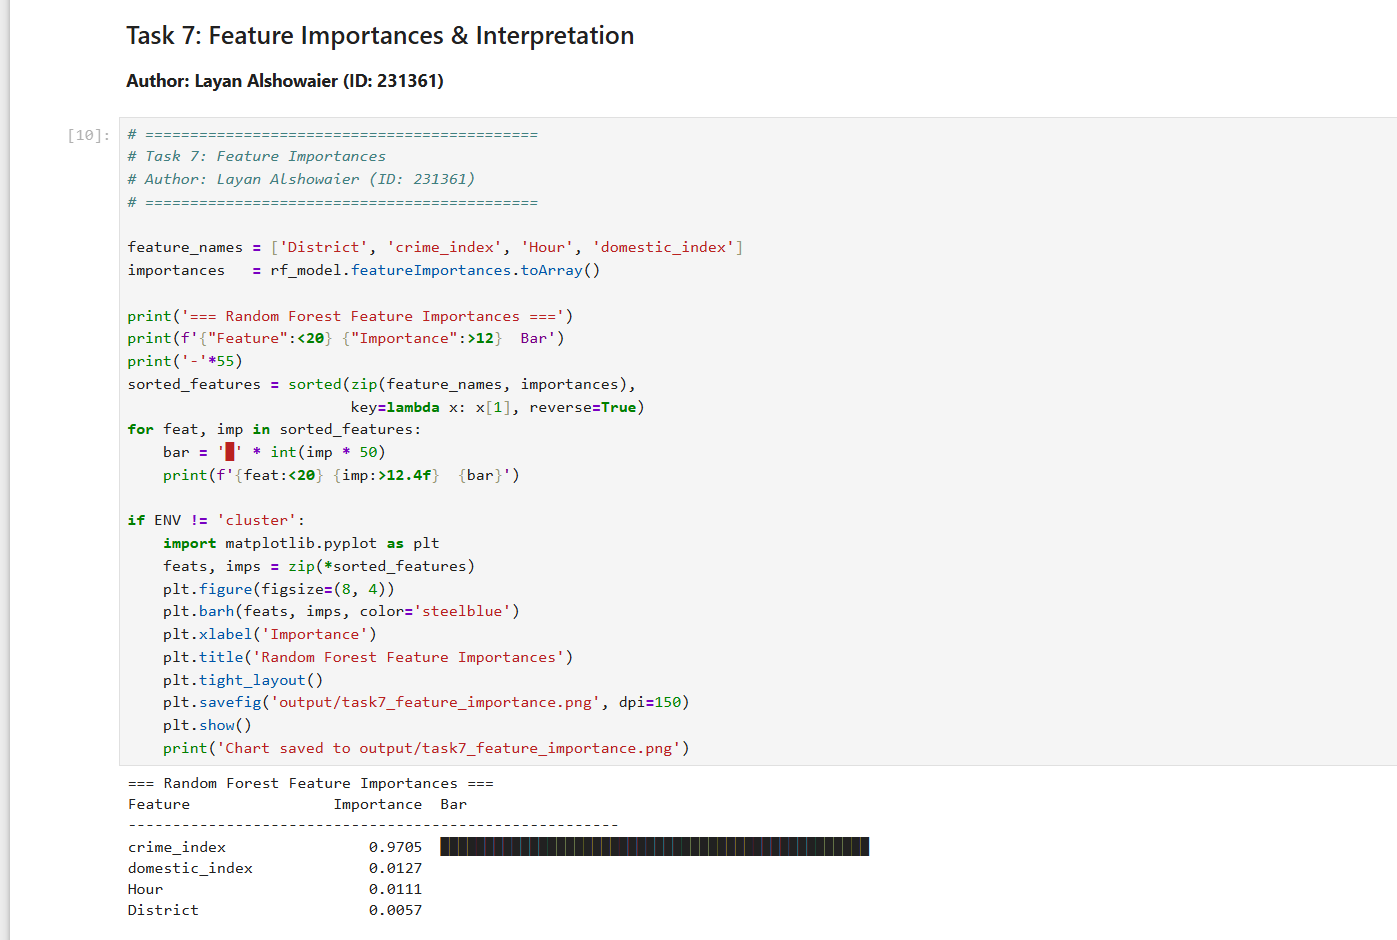



### Task 11: spark-submit — Cluster Mode
**Author: Moudi Alsadoon (ID: 231589)**
```bash
spark-submit \
    --master yarn \
    --deploy-mode cluster \
    --driver-memory 512m \
    --num-executors 1 \
    --executor-memory 1g \
    --executor-cores 1 \
    --conf spark.driver.maxResultSize=128m \
    --conf spark.yarn.appMasterEnv.PYSPARK_PYTHON=python3.12 \
    --conf spark.executorEnv.PYSPARK_PYTHON=python3.12 \
    m2_spark_ml.py
```



In [ ]:
spark.stop()
print('SparkSession stopped. Notebook complete!')